In [7]:
import pandas as pd
from isotree import IsolationForest

In [8]:
data = pd.read_parquet("data/final_32_columns.parquet")

In [9]:
eif = IsolationForest(ndim=2, ntrees=250, random_seed=42)

In [5]:
from isotree import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np

# ---- 1. Separate features and target ----
target = "totalFare"
features = [col for col in data.columns if col != target]

X = data[features].copy()

# ---- 2. Scale (important for EIF) ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- 3. Train EIF ----
iso = IsolationForest(
    ntrees=400,          # more trees for stability (large dataset)
    sample_size=512,     # better structure capture
    ndim=3,              # captures interactions
    ntry=10,
    random_seed=42
)

iso.fit(X_scaled)

# ---- 4. Scores ----
scores = iso.predict(X_scaled)     # higher = normal
anomaly_score = -scores            # higher = more anomalous

data["anomaly_score"] = anomaly_score

In [15]:
# You will need to install the library first: pip install isotree
from isotree import IsolationForest

# 1. Define the features that contextualize the price
features = ['totalFare', 'travelDuration', 'numDaysToFlight']

# Drop NaNs from the subset we are modeling
df_model = data.dropna(subset=features).copy()

# 2. Initialize the Extended Isolation Forest
# The magic parameter is 'ndim'. 
# ndim=1 is standard axis-parallel IForest. 
# ndim=2 (or higher) enables the Extended sloped hyperplanes.
eif_model = IsolationForest(ndim=2, ntrees=100, random_seed=42)

print("Fitting Extended Isolation Forest... (Slicing with sloped hyperplanes)")

# 3. Fit and predict anomaly scores
# Unlike scikit-learn, isotree returns a continuous anomaly score from 0 to 1.
# Scores closer to 1 are extreme anomalies.
df_model['anomaly_score'] = eif_model.fit_predict(df_model[features])

# 4. Set a dynamic threshold (e.g., dropping the top 2% most anomalous scores)
threshold = df_model['anomaly_score'].quantile(0.98)

# Filter out the anomalies (keeping only scores below the threshold)
df_pruned_eif = df_model[df_model['anomaly_score'] < threshold].copy()

# Clean up the dataframe
df_final = df_pruned_eif.drop(columns=['anomaly_score'])

print(f"Threshold set at anomaly score: {threshold:.4f}")
print(f"Removed {len(df_model) - len(df_final)} contextual outliers using EIF.")

Fitting Extended Isolation Forest... (Slicing with sloped hyperplanes)


/home/aryan-bodhe/venvs/deep_learning/lib/python3.12/site-packages/isotree/__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
/home/aryan-bodhe/venvs/deep_learning/lib/python3.12/site-packages/isotree/__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


Threshold set at anomaly score: 0.4825
Removed 16427 contextual outliers using EIF.


In [14]:
# You will need to install the library first: pip install isotree
from isotree import IsolationForest

# 1. Define the features that contextualize the price
features = [
    'totalFare',
    'travelDuration',
    'numDaysToFlight',
    'totalTravelDistance',
    'seatsRemaining',
    'numLayovers'
]

# Drop NaNs from the subset we are modeling
df_model = data.dropna(subset=features).copy()

# 2. Initialize the Extended Isolation Forest
# The magic parameter is 'ndim'. 
# ndim=1 is standard axis-parallel IForest. 
# ndim=2 (or higher) enables the Extended sloped hyperplanes.
eif_model = IsolationForest(ndim=2, ntrees=100, random_seed=42)

print("Fitting Extended Isolation Forest... (Slicing with sloped hyperplanes)")

# 3. Fit and predict anomaly scores
# Unlike scikit-learn, isotree returns a continuous anomaly score from 0 to 1.
# Scores closer to 1 are extreme anomalies.
df_model['anomaly_score'] = eif_model.fit_predict(df_model[features])

# 4. Set a dynamic threshold (e.g., dropping the top 2% most anomalous scores)
threshold = df_model['anomaly_score'].quantile(0.98)

# Filter out the anomalies (keeping only scores below the threshold)
df_pruned_eif = df_model[df_model['anomaly_score'] < threshold].copy()

# Clean up the dataframe
df_final2 = df_pruned_eif.drop(columns=['anomaly_score'])

print(f"Threshold set at anomaly score: {threshold:.4f}")
print(f"Removed {len(df_model) - len(df_final)} contextual outliers using EIF.")

Fitting Extended Isolation Forest... (Slicing with sloped hyperplanes)


/home/aryan-bodhe/venvs/deep_learning/lib/python3.12/site-packages/isotree/__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
/home/aryan-bodhe/venvs/deep_learning/lib/python3.12/site-packages/isotree/__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


Threshold set at anomaly score: 0.4744
Removed 16427 contextual outliers using EIF.


In [ ]:
len(df_final2)

804910

In [12]:
df_final.to_parquet("data/final_32_columns_no_outliers.parquet")

In [ ]:
outliers_old = set(df_final.index[df_final['anomaly_score'] >= threshold])
outliers_new = set(df_final2.indbex[df_final2['anomaly_score'] >= threshold])

overlap = len(outliers_old & outliers_new) / len(outliers_old)

print(f"Overlap: {overlap:.2%}")

KeyError: 'anomaly_score'

In [17]:
set_old = set(df_final.index)
set_new = set(df_final2.index)

# intersection
common = set_old & set_new

# differences
only_old = set_old - set_new
only_new = set_new - set_old

print(f"Common rows: {len(common)}")
print(f"Only in old: {len(only_old)}")
print(f"Only in new: {len(only_new)}")

print(f"Overlap %: {len(common) / len(set_old) * 100:.2f}%")

Common rows: 796407
Only in old: 8503
Only in new: 8503
Overlap %: 98.94%


In [5]:
import matplotlib.pylab as plt
import seaborn as sns
import numpy as np

In [10]:
data = pd.read_parquet("data/final_32_columns_no_outliers.parquet")

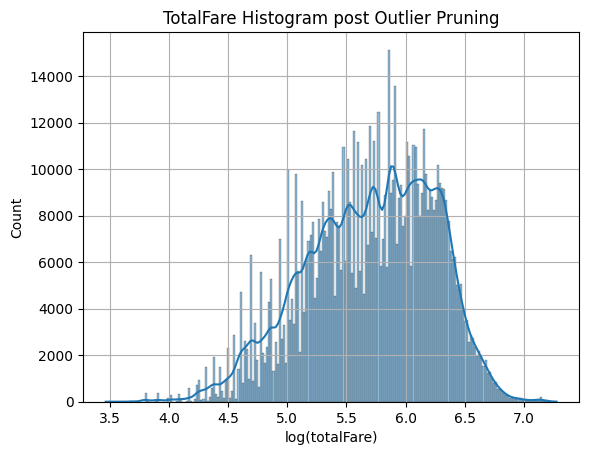

In [23]:
sns.histplot(np.log1p(data.totalFare), kde=True)
plt.title("TotalFare Histogram post Outlier Pruning")
plt.xlabel("log(totalFare)")
plt.grid(True)
plt.savefig("plots/totalFare_histplot_post_eif.png")
plt.show()

In [13]:
from scipy.stats import kurtosis, skew

In [18]:
kts = kurtosis(np.log1p(data.totalFare), fisher=False)
skw = skew(np.log1p(data.totalFare))

In [19]:
print(f"Skew = {skw}, Kurtosis = {kts}.")

Skew = -0.361882173758815, Kurtosis = 2.616099537071685.
